# Bluesky Moderation — Full IAA & Precision/Recall Analysis
**NeurIPS Paper · MPI SWS**

Two surveys:
- **Main survey** (3K curated posts): Ines=800, adash=786, soumidas=100
- **Firehose survey** (1K random): Ines=1001, adash=806, soumidas=302

Bluesky official labeler used as **predicted**, human annotations as **ground truth** (firehose only).

## 1. Imports & Setup

In [25]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             classification_report)
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

DISPLAY_NUM_OFFSET = 10000

ANN_PATH = "Bluesky Moderation Annotations.csv"
POSTS_MAIN = "combined_3k.jsonl"
POSTS_FH   = "firehose_1k_labeled.jsonl"

## 2. Load Data

In [26]:
ann = pd.read_csv(ANN_PATH)
ann.columns = ann.columns.str.strip()
print(f"Loaded {len(ann)} rows from CSV")
ann.head(3)

main_ann = ann[ann["display_num"] < DISPLAY_NUM_OFFSET].copy()
fh_ann = ann[ann["display_num"] >= DISPLAY_NUM_OFFSET].copy()
fh_ann["display_num_norm"] = fh_ann["display_num"] - DISPLAY_NUM_OFFSET

print(f"Main: {len(main_ann)} rows")
print(f"Firehose: {len(fh_ann)} rows")

Loaded 3810 rows from CSV
Main: 1701 rows
Firehose: 2109 rows


In [27]:
def load_jsonl(path):
    posts = {}
    try:
        with open(path) as f:
            for line in f:
                if line.strip():
                    p = json.loads(line)
                    if p.get('uri'):
                        posts[p['uri']] = p
        print(f"Loaded {len(posts):,} posts — {path.split('/')[-1]}")
    except FileNotFoundError:
        print(f"NOT FOUND: {path}")
    return posts

main_posts = load_jsonl(POSTS_MAIN)
fh_posts   = load_jsonl(POSTS_FH)

# Join source to main annotations
main_ann['source'] = main_ann['post_id'].map(
    lambda u: main_posts.get(u,{}).get('source','unknown'))

# Join Bluesky labels to firehose annotations
fh_ann['bluesky_labels']  = fh_ann['post_id'].map(
    lambda u: fh_posts.get(u,{}).get('bluesky_labels', []))
fh_ann['bluesky_flagged'] = fh_ann['bluesky_labels'].apply(
    lambda x: 'Unsafe' if isinstance(x,list) and len(x)>0 else 'Safe')


Loaded 3,000 posts — combined_3k.jsonl
Loaded 1,000 posts — firehose_1k_labeled.jsonl


## 3. Helpers

In [28]:
def build_lookup(df, name):
    sub = df[df['annotator_name']==name]
    return dict(zip(sub['post_id'], sub['label']))

def iaa(common, lu_a, lu_b, name_a, name_b, label=''):
    la = [lu_a[p] for p in common]
    lb = [lu_b[p] for p in common]
    agree = sum(x==y for x,y in zip(la,lb))
    pct   = 100*agree/len(common)
    try:    kappa = cohen_kappa_score(la,lb)
    except: kappa = float('nan')
    interp = ('almost perfect' if kappa>=0.8 else 'substantial' if kappa>=0.6
              else 'moderate' if kappa>=0.4 else 'fair' if kappa>=0.2 else 'poor')
    tag = f' [{label}]' if label else ''
    print(f"  {name_a} vs {name_b}{tag}:  n={len(common)}  "
          f"agree={agree} ({pct:.1f}%)  κ={kappa:.3f} ({interp})")
    return dict(pair=f'{name_a} vs {name_b}', subset=label, n=len(common),
                pct=round(pct,1), kappa=round(kappa,3), interp=interp, la=la, lb=lb)

def cm_plot(axes_list, pairs, cmap='Blues', suptitle=''):
    for ax,(a,b,common,lad,lbd) in zip(axes_list, pairs):
        la2=[lad[p] for p in common]; lb2=[lbd[p] for p in common]
        k2=cohen_kappa_score(la2,lb2); ag2=sum(x==y for x,y in zip(la2,lb2))
        cats=['Safe','Unsafe']
        sns.heatmap(pd.DataFrame(confusion_matrix(la2,lb2,labels=cats),
                    index=[f'{a}: {c}' for c in cats],
                    columns=[f'{b}: {c}' for c in cats]),
                    annot=True,fmt='d',cmap=cmap,ax=ax,cbar=False,
                    linewidths=0.5,linecolor='white')
        ax.set_title(f'{a} vs {b}\nn={len(common)}  κ={k2:.2f}')
    if suptitle:
        plt.suptitle(suptitle, fontsize=12, y=1.02)


---
# Part A — Main Survey

## A1. Label Distribution

In [29]:
lu_m_ines  = build_lookup(main_ann,'Ines')
lu_m_adash = build_lookup(main_ann,'adash')
lu_m_soumi = build_lookup(main_ann,'soumidas')

dist = main_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0)
dist['total'] = dist.sum(axis=1)
dist['% unsafe'] = (dist.get('Unsafe',0)/dist['total']*100).round(1)
print(dist)


label           Safe  Unsafe  total  % unsafe
annotator_name                               
Ines             599     201    800      25.1
adash            563     238    801      29.7
soumidas          68      32    100      32.0


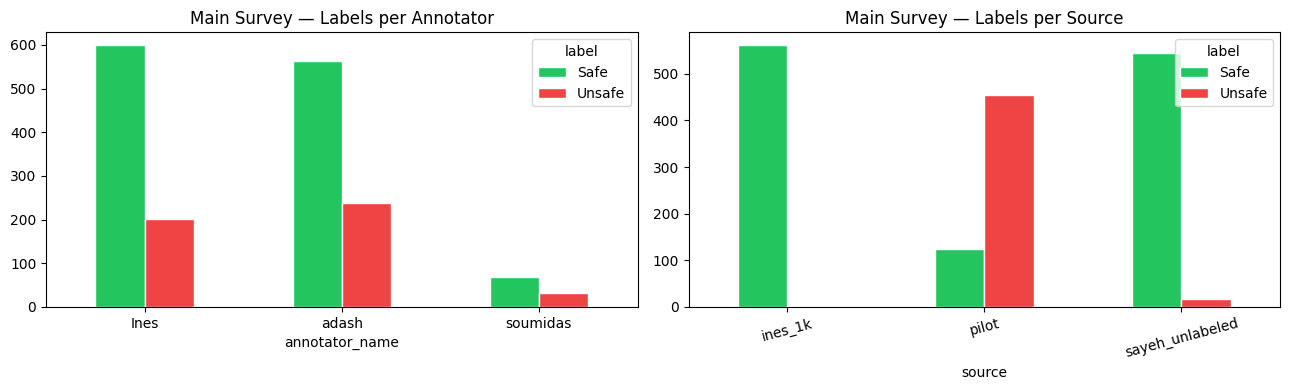

In [30]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
main_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0).plot(
    kind='bar',ax=axes[0],color=['#22c55e','#ef4444'],edgecolor='white')
axes[0].set_title('Main Survey — Labels per Annotator'); axes[0].tick_params(axis='x',rotation=0)

main_ann.groupby(['source','label']).size().unstack(fill_value=0).plot(
    kind='bar',ax=axes[1],color=['#22c55e','#ef4444'],edgecolor='white')
axes[1].set_title('Main Survey — Labels per Source'); axes[1].tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.savefig('main_label_dist.png',dpi=150,bbox_inches='tight'); plt.show()


## A2. Pairwise IAA

In [37]:
print("=== MAIN SURVEY — PAIRWISE IAA ===\n")
common_m_ia  = sorted(set(lu_m_ines) & set(lu_m_adash))
common_m_is  = sorted(set(lu_m_ines) & set(lu_m_soumi))
common_m_as  = sorted(set(lu_m_adash)& set(lu_m_soumi))
common_m_all = sorted(set(lu_m_ines) & set(lu_m_adash) & set(lu_m_soumi))

r_m_ia  = iaa(common_m_ia,  lu_m_ines, lu_m_adash,'Ines','adash')
r_m_is  = iaa(common_m_is,  lu_m_ines, lu_m_soumi,'Ines','soumidas')
r_m_as  = iaa(common_m_as,  lu_m_adash,lu_m_soumi,'adash','soumidas')
print(f"\n  All 3 overlap: {len(common_m_all)} posts")
if common_m_all:
    iaa(common_m_all, lu_m_ines, lu_m_adash,'Ines','adash','all3-subset')


=== MAIN SURVEY — PAIRWISE IAA ===

  Ines vs adash:  n=800  agree=738 (92.2%)  κ=0.806 (almost perfect)
  Ines vs soumidas:  n=100  agree=90 (90.0%)  κ=0.754 (substantial)
  adash vs soumidas:  n=100  agree=95 (95.0%)  κ=0.882 (almost perfect)

  All 3 overlap: 100 posts
  Ines vs adash [all3-subset]:  n=100  agree=93 (93.0%)  κ=0.821 (almost perfect)


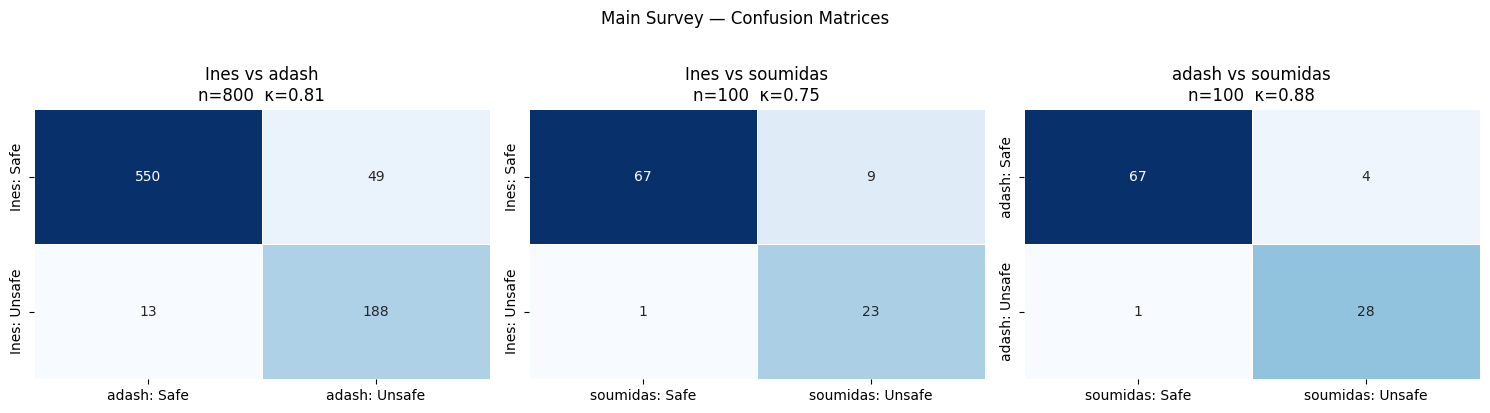

In [32]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
cm_plot(axes,[('Ines','adash',common_m_ia,lu_m_ines,lu_m_adash),
              ('Ines','soumidas',common_m_is,lu_m_ines,lu_m_soumi),
              ('adash','soumidas',common_m_as,lu_m_adash,lu_m_soumi)],
        cmap='Blues', suptitle='Main Survey — Confusion Matrices')
plt.tight_layout(); plt.savefig('main_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## A3. IAA by Source (Ines vs adash)

In [38]:
SOURCES = ['ines_1k','sayeh_unlabeled','pilot']
print("=== MAIN SURVEY — IAA BY SOURCE (Ines vs adash) ===\n")
src_rows = []
for src in SOURCES:
    src_posts = [p for p in common_m_ia
                 if main_posts.get(p,{}).get('source','')==src]
    if src_posts:
        r = iaa(src_posts, lu_m_ines, lu_m_adash,'Ines','adash', src)
        src_rows.append({'Source':src,'n':r['n'],'Agreement (%)':r['pct'],
                         "Cohen's κ":r['kappa'],'Interpretation':r['interp']})
pd.DataFrame(src_rows)


=== MAIN SURVEY — IAA BY SOURCE (Ines vs adash) ===

  Ines vs adash [ines_1k]:  n=264  agree=264 (100.0%)  κ=nan (poor)
  Ines vs adash [sayeh_unlabeled]:  n=264  agree=261 (98.9%)  κ=0.764 (substantial)
  Ines vs adash [pilot]:  n=272  agree=213 (78.3%)  κ=0.379 (fair)


,Source,n,Agreement (%),Cohen's κ,Interpretation
0,ines_1k,264,100.0,NaN,poor
1,sayeh_unlabeled,264,98.9,0.764,substantial
2,pilot,272,78.3,0.379,fair


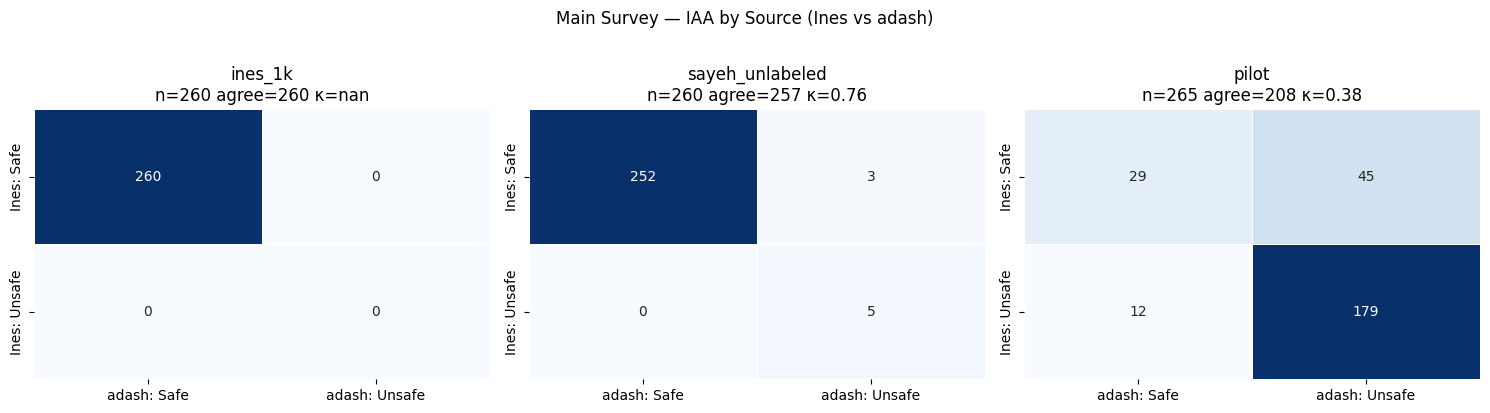

In [12]:
if src_rows:
    df_src = pd.DataFrame(src_rows)
    fig, axes = plt.subplots(1,len(SOURCES),figsize=(15,4))
    for ax,src in zip(axes,SOURCES):
        src_posts=[p for p in common_m_ia
                   if main_posts.get(p,{}).get('source','')==src]
        if not src_posts: continue
        la2=[lu_m_ines[p] for p in src_posts]; lb2=[lu_m_adash[p] for p in src_posts]
        k2=cohen_kappa_score(la2,lb2)
        cats=['Safe','Unsafe']
        sns.heatmap(pd.DataFrame(confusion_matrix(la2,lb2,labels=cats),
            index=[f'Ines: {c}' for c in cats],
            columns=[f'adash: {c}' for c in cats]),
            annot=True,fmt='d',cmap='Blues',ax=ax,cbar=False,
            linewidths=0.5,linecolor='white')
        ag2=sum(x==y for x,y in zip(la2,lb2))
        ax.set_title(f'{src}\nn={len(src_posts)} agree={ag2} κ={k2:.2f}')
    plt.suptitle('Main Survey — IAA by Source (Ines vs adash)',fontsize=12,y=1.02)
    plt.tight_layout(); plt.savefig('main_source_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## A4. Disagreements (Main)

In [13]:
rows=[]
for p in common_m_ia:
    if lu_m_ines[p] != lu_m_adash[p]:
        rows.append({'source':main_posts.get(p,{}).get('source','?'),
                     'Ines':lu_m_ines[p],'adash':lu_m_adash[p],
                     'post_id':p[-35:],
                     'text':str(main_posts.get(p,{}).get('text',''))[:100]})
d_main = pd.DataFrame(rows)
print(f"Main disagreements (Ines vs adash): {len(d_main)}/{len(common_m_ia)} ({100*len(d_main)/len(common_m_ia):.1f}%)")
print("By source:"); print(d_main.groupby('source').size().to_string())
d_main.head(10)


Main disagreements (Ines vs adash): 60/785 (7.6%)
By source:
source
pilot              57
sayeh_unlabeled     3


,source,Ines,adash,post_id,text
0,pilot,Unsafe,Safe,k7/app.bsky.feed.post/3m4a2ndxbtc2z,Day 27: THE GIRL WITH ALL THE GIFTS (2016)\nA pretty good film that lost to ...
1,pilot,Unsafe,Safe,hf/app.bsky.feed.post/3ls5wsf4xjk2w,israeli PM stroked the orange snollygosters ego and that got Iran bombed by ...
2,pilot,Safe,Unsafe,i5/app.bsky.feed.post/3lo4nul75g22x,"Thank you @emmaexhibition.bsky.social for the beautiful reference, and for c..."
3,pilot,Safe,Unsafe,6q/app.bsky.feed.post/3lvyled6yxc24,"Fuck off, christians with tiny penises."
4,pilot,Safe,Unsafe,j2/app.bsky.feed.post/3lwhg4fu6ls2p,i'm not dead yet
5,pilot,Safe,Unsafe,k6/app.bsky.feed.post/3m7vpfoqht22b,Commission done for Kiwiboba on discord!\n#digitalart #art #drawing #fanart ...
6,pilot,Safe,Unsafe,n7/app.bsky.feed.post/3lknbp2ulfj2m,
7,pilot,Safe,Unsafe,rb/app.bsky.feed.post/3lsycdzebg22o,Funeral celebration?
8,pilot,Safe,Unsafe,zd/app.bsky.feed.post/3lt3x4hb7qk2k,You're really a smug asshole. Eat it. You miss all the points!!!
9,pilot,Unsafe,Safe,fu/app.bsky.feed.post/3lyv6lueam22l,Silksoles\n\n#feet #feetsky #silksong


---
# Part B — Firehose Survey

## B1. Label Distribution

In [33]:
lu_f_ines  = build_lookup(fh_ann,'Ines')
lu_f_adash = build_lookup(fh_ann,'adash')
lu_f_soumi = build_lookup(fh_ann,'soumidas')

dist_fh = fh_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0)
dist_fh['total']    = dist_fh.sum(axis=1)
dist_fh['% unsafe'] = (dist_fh.get('Unsafe',0)/dist_fh['total']*100).round(1)
print(dist_fh)

n_bsky = sum(1 for p in fh_posts.values() if p.get('bluesky_labels'))
print(f"\nBluesky flagged: {n_bsky}/{len(fh_posts)} ({100*n_bsky/len(fh_posts):.1f}%) of all firehose posts")


label           Safe  Unsafe  total  % unsafe
annotator_name                               
Ines             981      20   1001       2.0
adash            769      37    806       4.6
soumidas         269      33    302      10.9

Bluesky flagged: 6/1000 (0.6%) of all firehose posts


## B2. Step 1 — Ines vs adash IAA

In [34]:
print("=== FIREHOSE — INES vs ADASH ===\n")
common_f_ia = sorted(set(lu_f_ines) & set(lu_f_adash))
r_f_ia = iaa(common_f_ia, lu_f_ines, lu_f_adash,'Ines','adash')
print()
la=[lu_f_ines[p] for p in common_f_ia]; lb=[lu_f_adash[p] for p in common_f_ia]
print(classification_report(la,lb,target_names=['Safe','Unsafe']))


=== FIREHOSE — INES vs ADASH ===

  Ines vs adash:  n=804  agree=776 (96.5%)  κ=0.466 (moderate)

              precision    recall  f1-score   support

        Safe       0.99      0.97      0.98       786
      Unsafe       0.36      0.72      0.48        18

    accuracy                           0.97       804
   macro avg       0.68      0.85      0.73       804
weighted avg       0.98      0.97      0.97       804



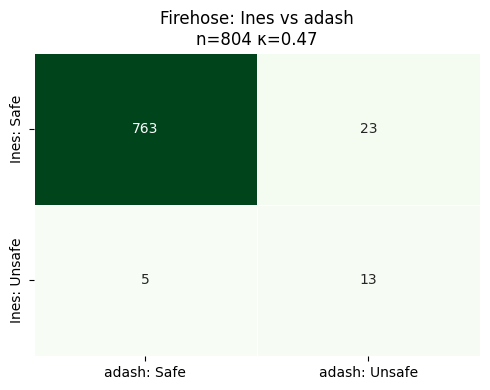

In [35]:
fig, ax = plt.subplots(figsize=(5,4))
la=[lu_f_ines[p] for p in common_f_ia]; lb=[lu_f_adash[p] for p in common_f_ia]
k=cohen_kappa_score(la,lb); cats=['Safe','Unsafe']
sns.heatmap(pd.DataFrame(confusion_matrix(la,lb,labels=cats),
    index=[f'Ines: {c}' for c in cats],
    columns=[f'adash: {c}' for c in cats]),
    annot=True,fmt='d',cmap='Greens',ax=ax,cbar=False,linewidths=0.5,linecolor='white')
ax.set_title(f'Firehose: Ines vs adash\nn={len(common_f_ia)} κ={k:.2f}')
plt.tight_layout(); plt.savefig('fh_ines_adash.png',dpi=150,bbox_inches='tight'); plt.show()


## B3. Step 2 — soumidas as Tiebreaker

In [36]:
print("=== FIREHOSE — WITH TIEBREAKER (soumidas) ===\n")
common_f_is  = sorted(set(lu_f_ines) & set(lu_f_soumi))
common_f_as  = sorted(set(lu_f_adash)& set(lu_f_soumi))
common_f_all = sorted(set(lu_f_ines) & set(lu_f_adash) & set(lu_f_soumi))

r_f_is = iaa(common_f_is,  lu_f_ines, lu_f_soumi,'Ines','soumidas')
r_f_as = iaa(common_f_as,  lu_f_adash,lu_f_soumi,'adash','soumidas')
print(f"\n  All 3 overlap: {len(common_f_all)} posts")
if common_f_all:
    iaa(common_f_all, lu_f_ines, lu_f_adash,'Ines','adash','all3-subset')

# How many Ines-adash disagreements did soumidas resolve?
disagree = [p for p in common_f_ia if lu_f_ines[p]!=lu_f_adash[p]]
soumi_on = [p for p in disagree if p in lu_f_soumi]
print(f"\n  Ines-adash disagreements: {len(disagree)}")
print(f"  soumidas labeled {len(soumi_on)} of those")
if soumi_on:
    sided = {'Ines':0,'adash':0,'neither':0}
    for p in soumi_on:
        s=lu_f_soumi[p]
        if s==lu_f_ines[p]: sided['Ines']+=1
        elif s==lu_f_adash[p]: sided['adash']+=1
        else: sided['neither']+=1
    print(f"  Sided with: {sided}")


=== FIREHOSE — WITH TIEBREAKER (soumidas) ===

  Ines vs soumidas:  n=302  agree=271 (89.7%)  κ=0.177 (poor)
  adash vs soumidas:  n=302  agree=275 (91.1%)  κ=0.363 (fair)

  All 3 overlap: 302 posts
  Ines vs adash [all3-subset]:  n=302  agree=290 (96.0%)  κ=0.315 (fair)

  Ines-adash disagreements: 28
  soumidas labeled 12 of those
  Sided with: {'Ines': 4, 'adash': 8, 'neither': 0}


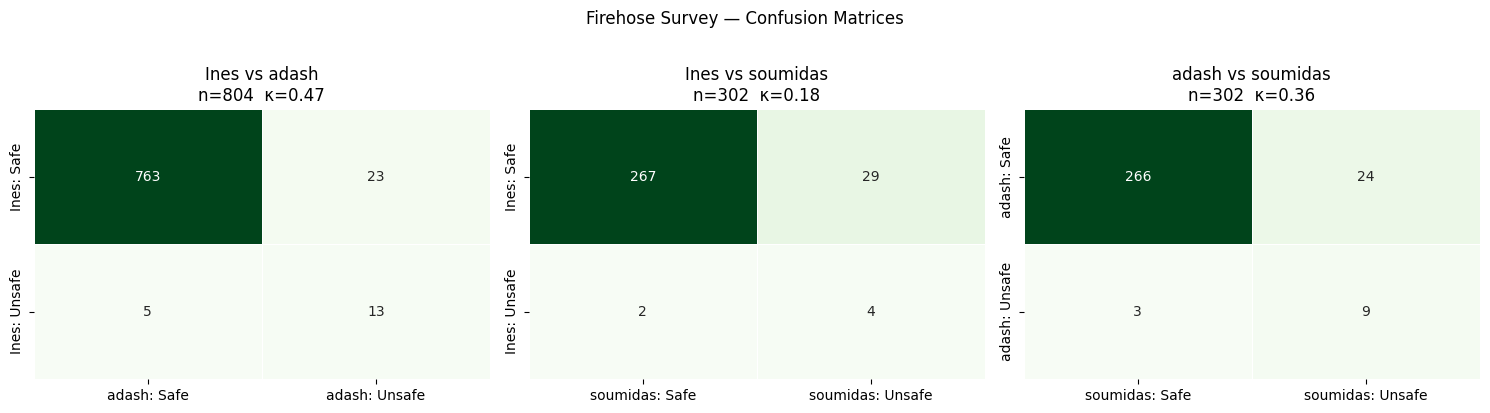

In [18]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
cm_plot(axes,[('Ines','adash',common_f_ia,lu_f_ines,lu_f_adash),
              ('Ines','soumidas',common_f_is,lu_f_ines,lu_f_soumi),
              ('adash','soumidas',common_f_as,lu_f_adash,lu_f_soumi)],
        cmap='Greens', suptitle='Firehose Survey — Confusion Matrices')
plt.tight_layout(); plt.savefig('fh_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## B4. Majority Vote Label

In [19]:
mv = {}
if common_f_all:
    for p in common_f_all:
        votes=[lu_f_ines[p],lu_f_adash[p],lu_f_soumi[p]]
        mv[p]='Unsafe' if votes.count('Unsafe')>=2 else 'Safe'
    n_u=sum(1 for v in mv.values() if v=='Unsafe')
    print(f"Majority vote (n={len(mv)}): Unsafe={n_u} ({100*n_u/len(mv):.1f}%)  Safe={len(mv)-n_u} ({100*(len(mv)-n_u)/len(mv):.1f}%)")
    for name,lu in [('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]:
        ag=sum(lu[p]==mv[p] for p in common_f_all)
        print(f"  {name} agrees with majority: {ag}/{len(common_f_all)} ({100*ag/len(common_f_all):.1f}%)")


Majority vote (n=302): Unsafe=10 (3.3%)  Safe=292 (96.7%)
  Ines agrees with majority: 294/302 (97.4%)
  adash agrees with majority: 298/302 (98.7%)
  soumidas agrees with majority: 279/302 (92.4%)


## B5. Precision & Recall vs Bluesky Labels

In [20]:
print("=== FIREHOSE — PRECISION/RECALL (Bluesky=predicted, Human=ground truth) ===\n")

all_fh_uris = sorted(set(lu_f_ines)|set(lu_f_adash)|set(lu_f_soumi))
n_bsky_total = sum(1 for u in all_fh_uris if fh_posts.get(u,{}).get('bluesky_labels'))
print(f"Base rates (all annotated posts, n={len(all_fh_uris)}):")
print(f"  Bluesky flagged: {n_bsky_total} ({100*n_bsky_total/len(all_fh_uris):.1f}%)")
for name,lu in [('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]:
    n_u=sum(1 for v in lu.values() if v=='Unsafe')
    print(f"  {name} unsafe:   {n_u}/{len(lu)} ({100*n_u/len(lu):.1f}%)")


=== FIREHOSE — PRECISION/RECALL (Bluesky=predicted, Human=ground truth) ===

Base rates (all annotated posts, n=1000):
  Bluesky flagged: 6 (0.6%)
  Ines unsafe:   20/1000 (2.0%)
  adash unsafe:   36/804 (4.5%)
  soumidas unsafe:   33/302 (10.9%)


In [21]:
pr_rows=[]
for name,lu in [('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]:
    sub=fh_ann[fh_ann['annotator_name']==name].copy()
    sub=sub[sub['post_id'].isin(lu)]
    y_true=sub['label'].map({'Safe':0,'Unsafe':1}).values
    y_pred=sub['bluesky_flagged'].map({'Safe':0,'Unsafe':1}).values
    p=precision_score(y_true,y_pred,zero_division=0)
    r=recall_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    n_bsky_f=y_pred.sum(); n_h_u=y_true.sum()
    n_both=((y_true==1)&(y_pred==1)).sum()
    n_only_bsky=((y_true==0)&(y_pred==1)).sum()
    n_only_human=((y_true==1)&(y_pred==0)).sum()
    print(f"{name} (n={len(y_true)}):")
    print(f"  Bluesky flagged: {n_bsky_f} ({100*n_bsky_f/len(y_true):.1f}%)  Human unsafe: {n_h_u} ({100*n_h_u/len(y_true):.1f}%)")
    print(f"  Both unsafe: {n_both}  Only Bluesky: {n_only_bsky}  Only Human: {n_only_human}")
    print(f"  Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}\n")
    pr_rows.append({'Annotator':name,'n':len(y_true),
                    'Bluesky (%)':round(100*n_bsky_f/len(y_true),1),
                    'Human unsafe (%)':round(100*n_h_u/len(y_true),1),
                    'Both':int(n_both),'Only Bsky':int(n_only_bsky),'Only Human':int(n_only_human),
                    'Precision':round(p,3),'Recall':round(r,3),'F1':round(f1,3)})

# Majority vote
if mv:
    y_true_mv=np.array([1 if mv[p]=='Unsafe' else 0 for p in common_f_all])
    y_pred_mv=np.array([1 if fh_posts.get(p,{}).get('bluesky_labels') else 0 for p in common_f_all])
    p=precision_score(y_true_mv,y_pred_mv,zero_division=0)
    r=recall_score(y_true_mv,y_pred_mv,zero_division=0)
    f1=f1_score(y_true_mv,y_pred_mv,zero_division=0)
    n_bsky_f=y_pred_mv.sum(); n_h_u=y_true_mv.sum()
    n_both=((y_true_mv==1)&(y_pred_mv==1)).sum()
    n_only_bsky=((y_true_mv==0)&(y_pred_mv==1)).sum()
    n_only_human=((y_true_mv==1)&(y_pred_mv==0)).sum()
    print(f"Majority vote (n={len(common_f_all)}):")
    print(classification_report(y_true_mv,y_pred_mv,target_names=['Safe','Unsafe']))
    pr_rows.append({'Annotator':'Majority vote','n':len(common_f_all),
                    'Bluesky (%)':round(100*n_bsky_f/len(common_f_all),1),
                    'Human unsafe (%)':round(100*n_h_u/len(common_f_all),1),
                    'Both':int(n_both),'Only Bsky':int(n_only_bsky),'Only Human':int(n_only_human),
                    'Precision':round(p,3),'Recall':round(r,3),'F1':round(f1,3)})

pr_df=pd.DataFrame(pr_rows)
pr_df


Ines (n=1001):
  Bluesky flagged: 6 (0.6%)  Human unsafe: 20 (2.0%)
  Both unsafe: 6  Only Bluesky: 0  Only Human: 14
  Precision: 1.000  Recall: 0.300  F1: 0.462

adash (n=806):
  Bluesky flagged: 6 (0.7%)  Human unsafe: 37 (4.6%)
  Both unsafe: 6  Only Bluesky: 0  Only Human: 31
  Precision: 1.000  Recall: 0.162  F1: 0.279

soumidas (n=302):
  Bluesky flagged: 0 (0.0%)  Human unsafe: 33 (10.9%)
  Both unsafe: 0  Only Bluesky: 0  Only Human: 33
  Precision: 0.000  Recall: 0.000  F1: 0.000

Majority vote (n=302):
              precision    recall  f1-score   support

        Safe       0.97      1.00      0.98       292
      Unsafe       0.00      0.00      0.00        10

    accuracy                           0.97       302
   macro avg       0.48      0.50      0.49       302
weighted avg       0.93      0.97      0.95       302



,Annotator,n,Bluesky (%),Human unsafe (%),Both,Only Bsky,Only Human,Precision,Recall,F1
0,Ines,1001,0.6,2.0,6,0,14,1.0,0.300,0.462
1,adash,806,0.7,4.6,6,0,31,1.0,0.162,0.279
2,soumidas,302,0.0,10.9,0,0,33,0.0,0.000,0.000
3,Majority vote,302,0.0,3.3,0,0,10,0.0,0.000,0.000


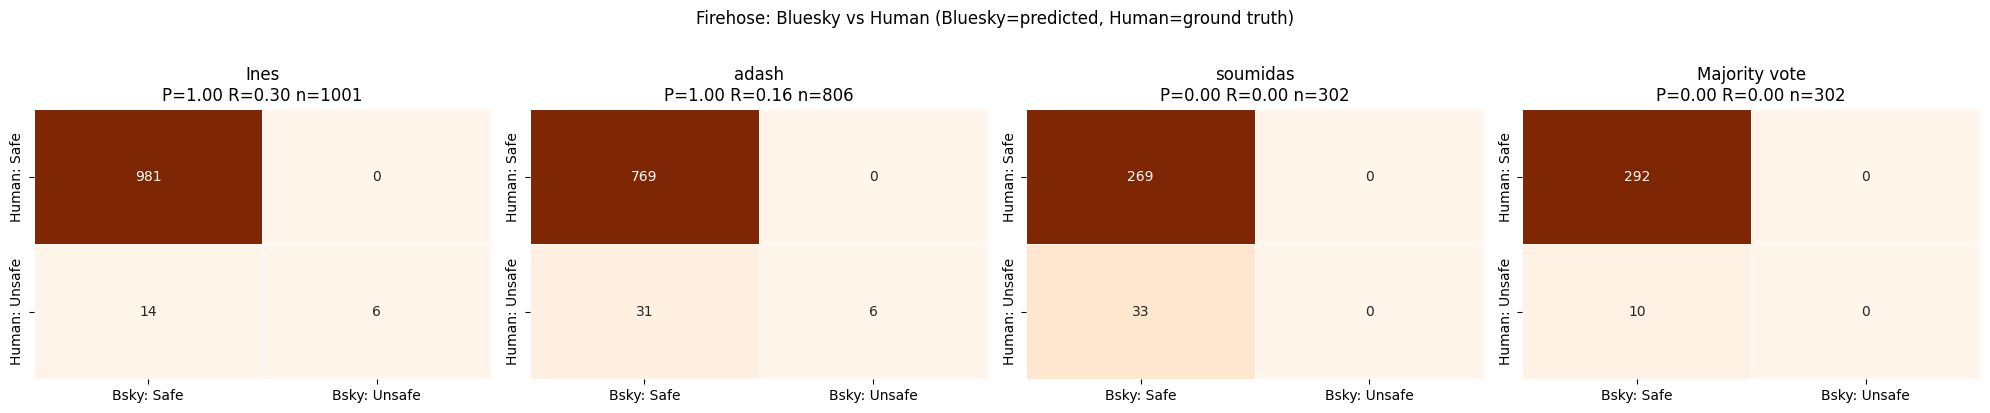

In [22]:
# Confusion matrices: Bluesky vs each annotator + majority vote
combos=[('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]
if mv: combos.append(('Majority vote',mv))
fig,axes=plt.subplots(1,len(combos),figsize=(5*len(combos),4))
for ax,(name,lu) in zip(axes,combos):
    if name=='Majority vote':
        posts=common_f_all; y_t=[1 if lu[p]=='Unsafe' else 0 for p in posts]
    else:
        sub=fh_ann[fh_ann['annotator_name']==name]
        posts=list(sub['post_id']); y_t=sub['label'].map({'Safe':0,'Unsafe':1}).tolist()
    y_p=[1 if fh_posts.get(p,{}).get('bluesky_labels') else 0 for p in posts]
    p_s=precision_score(y_t,y_p,zero_division=0); r_s=recall_score(y_t,y_p,zero_division=0)
    sns.heatmap(pd.DataFrame(confusion_matrix(y_t,y_p,labels=[0,1]),
        index=['Human: Safe','Human: Unsafe'],
        columns=['Bsky: Safe','Bsky: Unsafe']),
        annot=True,fmt='d',cmap='Oranges',ax=ax,cbar=False,linewidths=0.5,linecolor='white')
    ax.set_title(f'{name}\nP={p_s:.2f} R={r_s:.2f} n={len(posts)}')
plt.suptitle('Firehose: Bluesky vs Human (Bluesky=predicted, Human=ground truth)',fontsize=12,y=1.02)
plt.tight_layout(); plt.savefig('fh_pr_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


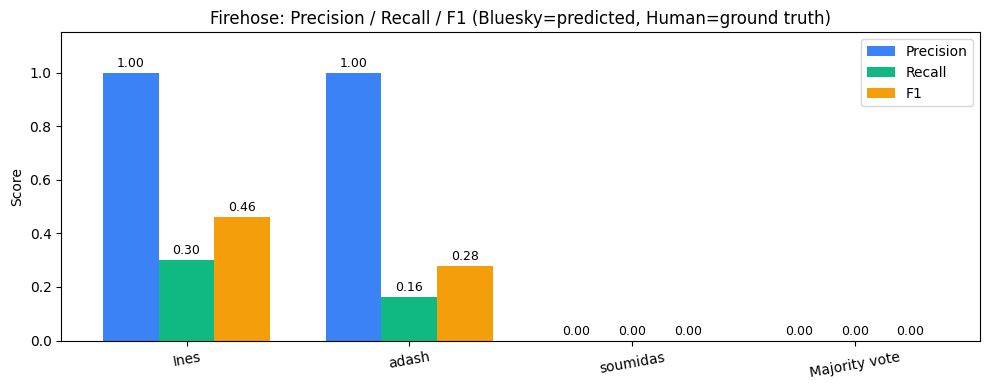

In [23]:
# Bar chart summary
fig,ax=plt.subplots(figsize=(10,4))
x=np.arange(len(pr_df)); w=0.25
ax.bar(x-w,pr_df['Precision'],w,label='Precision',color='#3b82f6')
ax.bar(x,  pr_df['Recall'],   w,label='Recall',   color='#10b981')
ax.bar(x+w,pr_df['F1'],       w,label='F1',       color='#f59e0b')
for i,row in pr_df.iterrows():
    for val,off in [(row['Precision'],-w),(row['Recall'],0),(row['F1'],w)]:
        ax.text(i+off,val+0.01,f'{val:.2f}',ha='center',va='bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(pr_df['Annotator'],rotation=10)
ax.set_ylim(0,1.15); ax.set_ylabel('Score')
ax.set_title('Firehose: Precision / Recall / F1 (Bluesky=predicted, Human=ground truth)')
ax.legend(); plt.tight_layout()
plt.savefig('fh_pr_bar.png',dpi=150,bbox_inches='tight'); plt.show()


---
# Summary Table for Paper

In [24]:
rows=[
    ['Main','Ines vs adash',   len(common_m_ia), r_m_ia['pct'], r_m_ia['kappa'], r_m_ia['interp'],'—','—','—'],
    ['Main','Ines vs soumidas',len(common_m_is), r_m_is['pct'], r_m_is['kappa'], r_m_is['interp'],'—','—','—'],
    ['Main','adash vs soumidas',len(common_m_as),r_m_as['pct'], r_m_as['kappa'], r_m_as['interp'],'—','—','—'],
    ['Firehose','Ines vs adash',   len(common_f_ia), r_f_ia['pct'], r_f_ia['kappa'], r_f_ia['interp'],
     pr_df[pr_df['Annotator']=='Ines']['Precision'].values[0],
     pr_df[pr_df['Annotator']=='Ines']['Recall'].values[0],
     pr_df[pr_df['Annotator']=='Ines']['F1'].values[0]],
    ['Firehose','Ines vs soumidas',len(common_f_is), r_f_is['pct'], r_f_is['kappa'], r_f_is['interp'],'—','—','—'],
    ['Firehose','adash vs soumidas',len(common_f_as),r_f_as['pct'], r_f_as['kappa'], r_f_as['interp'],'—','—','—'],
]
cols=['Survey','Pair','n','Agreement (%)','Cohen κ','Interpretation',
      'Precision (Bsky)','Recall (Bsky)','F1 (Bsky)']
summary=pd.DataFrame(rows,columns=cols)
print(summary.to_string(index=False))
summary


  Survey              Pair   n  Agreement (%)  Cohen κ Interpretation Precision (Bsky) Recall (Bsky) F1 (Bsky)
    Main     Ines vs adash 785           92.4    0.808 almost perfect                —             —         —
    Main  Ines vs soumidas 100           90.0    0.754    substantial                —             —         —
    Main adash vs soumidas 100           95.0    0.882 almost perfect                —             —         —
Firehose     Ines vs adash 804           96.5    0.466       moderate              1.0           0.3     0.462
Firehose  Ines vs soumidas 302           89.7    0.177           poor                —             —         —
Firehose adash vs soumidas 302           91.1    0.363           fair                —             —         —


,Survey,Pair,n,Agreement (%),Cohen κ,Interpretation,Precision (Bsky),Recall (Bsky),F1 (Bsky)
0,Main,Ines vs adash,785,92.4,0.808,almost perfect,—,—,—
1,Main,Ines vs soumidas,100,90.0,0.754,substantial,—,—,—
2,Main,adash vs soumidas,100,95.0,0.882,almost perfect,—,—,—
3,Firehose,Ines vs adash,804,96.5,0.466,moderate,1.0,0.3,0.462
4,Firehose,Ines vs soumidas,302,89.7,0.177,poor,—,—,—
5,Firehose,adash vs soumidas,302,91.1,0.363,fair,—,—,—


In [41]:
import pandas as pd, json

ann = pd.read_csv("Bluesky Moderation Annotations.csv")
ann.columns = ann.columns.str.strip()
main_ann = ann[ann["display_num"] < 10000]

posts_map = {}
with open("combined_3k.jsonl") as f:
    for line in f:
        if line.strip():
            p = json.loads(line)
            if p.get("uri"):
                posts_map[p["uri"]] = p

main_ann["source"] = main_ann["post_id"].map(
    lambda u: posts_map.get(u, {}).get("source", "unknown")
)

print(main_ann.groupby(["annotator_name", "source"]).size().unstack(fill_value=0))

source          ines_1k  pilot  sayeh_unlabeled
annotator_name                                 
Ines                264    272              264
adash               264    273              264
soumidas             33     34               33
